In [1]:
#ORDEN LETRAS
"""
LABELS = {
    'A' : 0,
    'B': 1,
    'C': 2,
    'D': 3,
    'E': 4,
    'F': 5,
    'G': 6,
    'H': 7,
    'I': 8,
    'J': 9,
    'K': 10,
    'L': 11,
    'M': 12,
    'N': 13,
    'O': 14,
    'P': 15,
    'Q': 16,
    'R': 17,
    'S': 18,
    'T': 19,
    'U': 20,
    'V': 21,
    'W': 22,
    'X': 23,
    'Y': 24,
    'Z': 25,
    'CH': 26,
    'Ñ': 27,
    'LL' : 28
}
"""

!unzip data_dinamico.zip

Archive:  data_dinamico.zip
   creating: data_dinamico/
   creating: data_dinamico/LL/
  inflating: data_dinamico/LL/LL_0.npy  
  inflating: data_dinamico/LL/LL_1.npy  
  inflating: data_dinamico/LL/LL_10.npy  
  inflating: data_dinamico/LL/LL_100.npy  
  inflating: data_dinamico/LL/LL_11.npy  
  inflating: data_dinamico/LL/LL_12.npy  
  inflating: data_dinamico/LL/LL_13.npy  
  inflating: data_dinamico/LL/LL_14.npy  
  inflating: data_dinamico/LL/LL_15.npy  
  inflating: data_dinamico/LL/LL_16.npy  
  inflating: data_dinamico/LL/LL_17.npy  
  inflating: data_dinamico/LL/LL_18.npy  
  inflating: data_dinamico/LL/LL_19.npy  
  inflating: data_dinamico/LL/LL_2.npy  
  inflating: data_dinamico/LL/LL_20.npy  
  inflating: data_dinamico/LL/LL_21.npy  
  inflating: data_dinamico/LL/LL_22.npy  
  inflating: data_dinamico/LL/LL_23.npy  
  inflating: data_dinamico/LL/LL_24.npy  
  inflating: data_dinamico/LL/LL_25.npy  
  inflating: data_dinamico/LL/LL_26.npy  
  inflating: data_dinamico/LL/LL_

Creación de un callback para parar el entrenamiento una vez el val_accuracy ha llegado a 1

In [2]:
import tensorflow as tf

class StopAtTargetAccuracy(tf.keras.callbacks.Callback):
    """
    Callback personalizado para detener el entrenamiento de Keras
    cuando la métrica val_categorical_accuracy alcanza o supera 1.0.
    """
    def __init__(self, target_accuracy=1.0):
        # Inicializamos con la precisión objetivo (por defecto, 1.0)
        super(StopAtTargetAccuracy, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        # 'logs' es un diccionario que contiene los valores de las métricas
        # del entrenamiento y validación al final de la época.

        # Obtenemos la precisión de validación
        val_acc = logs.get('val_categorical_accuracy')

        # Usamos un margen de seguridad (epsilon) para la comparación
        epsilon = 1e-6

        if val_acc is not None and val_acc >= (self.target_accuracy - epsilon):
            print(f'\n\n¡La Precisión de Validación Categórica ({val_acc:.4f}) ha alcanzado o superado 1.0 en el epoch {epoch + 1}!')
            self.model.stop_training = True

        # Si quieres ver la precisión en cada época:
        # else:
        #     print(f'\nÉpoca {epoch + 1}: val_categorical_accuracy = {val_acc:.4f}. Continúa entrenando.')

# ANTES DE EJECUTAR IMPORTR LA CARPETA data_dinamico

In [3]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns



# Configuración básica
DATA_PATH = 'data_dinamico' # Nombre de la carpeta donde están tus datos
actions = np.array(['V', 'X', 'Y', 'Z', 'LL']) # Las etiquetas
no_sequences = 30 # Longitud de la secuencia (misma que en el script de captura)
no_features = 42  # 21 puntos x 2 coordenadas (x, y)

Carga y Etiquetado de Datos

In [4]:
label_map = {label:num for num, label in enumerate(actions)}
print(f"Mapeo de etiquetas: {label_map}")

sequences, labels = [], []

for action in actions:
    # Ruta a la carpeta de cada letra
    action_path = os.path.join(DATA_PATH, action)

    # Listar todos los archivos .npy
    file_list = [f for f in os.listdir(action_path) if f.endswith('.npy')]

    print(f"Cargando {len(file_list)} secuencias para la clase '{action}'...")

    for file_name in file_list:
        # Cargar la secuencia (shape: 30, 42)
        window = np.load(os.path.join(action_path, file_name))

        sequences.append(window)
        labels.append(label_map[action])

print(f"\nDatos cargados exitosamente. Total de muestras: {len(sequences)}")

Mapeo de etiquetas: {np.str_('V'): 0, np.str_('X'): 1, np.str_('Y'): 2, np.str_('Z'): 3, np.str_('LL'): 4}
Cargando 101 secuencias para la clase 'V'...
Cargando 101 secuencias para la clase 'X'...
Cargando 101 secuencias para la clase 'Y'...
Cargando 101 secuencias para la clase 'Z'...
Cargando 101 secuencias para la clase 'LL'...

Datos cargados exitosamente. Total de muestras: 505


Preprocesamiento (X e y)

In [5]:
X = np.array(sequences)
y = to_categorical(labels).astype(int) # Convierte 0 en [1,0,0,0,0], 1 en [0,1,0,0,0], etc.

# División en Train (90%) y Test (10%)
# random_state asegura que siempre divida igual (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (454, 30, 42)
y_train shape: (454, 5)


Construcción del Modelo LSTM

In [6]:
model = Sequential()

# Capa LSTM 1
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 42)))

# Capa LSTM 2
model.add(LSTM(128, return_sequences=True, activation='relu'))

# Capa LSTM 3 (Opcional, para mayor complejidad)
model.add(LSTM(64, return_sequences=False, activation='relu'))

# Capas Densas para clasificación
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Capa de Salida (5 neuronas = 5 gestos)
model.add(Dense(actions.shape[0], activation='softmax'))

# Compilación
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        27,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,021 (711.02 KB)

 Trainable params: 182,021 (711.02 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento

In [8]:
checkpoint_path = "mejor_modelo.keras"
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# Create an instance of the custom callback
stop_at_accuracy_callback = StopAtTargetAccuracy(target_accuracy=1.0)

# Entrenamiento
history = model.fit(X_train, y_train,
                    epochs=150,           # Ajusta según veas la gráfica de loss
                    batch_size=32,
                    validation_split=0.1, # Usar 10% de los datos de entrenamiento para validación
                    callbacks=[checkpoint, stop_at_accuracy_callback])

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - categorical_accuracy: 0.2642 - loss: 1.5801
Epoch 1: val_loss improved from inf to 1.55498, saving model to mejor_modelo.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 464ms/step - categorical_accuracy: 0.2741 - loss: 1.5742 - val_categorical_accuracy: 0.4348 - val_loss: 1.5550
Epoch 2/150
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.4441 - loss: 1.2239
Epoch 2: val_loss improved from 1.55498 to 0.57191, saving model to mejor_modelo.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.4538 - loss: 1.2049 - val_categorical_accuracy: 0.7174 - val_loss: 0.5719
Epoch 3/150
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.6446 - loss: 0.8586
Epoch 3: val_loss improved from 0.57191 to 0.39442, saving model to mejor_modelo.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.6626 - loss: 0.8256 - val_categorical_accuracy: 0.8478 - val_loss: 0.3944
Epoch 4/150
11/13 ━━━━━━━━

Evaluación y Gráficas

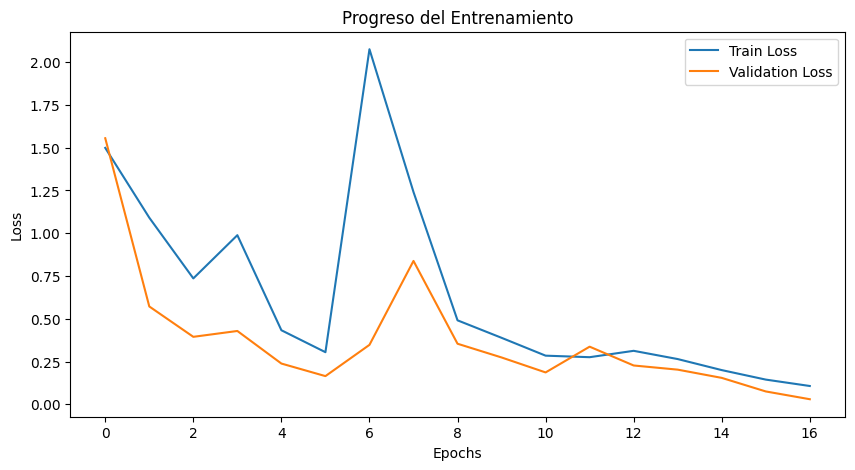

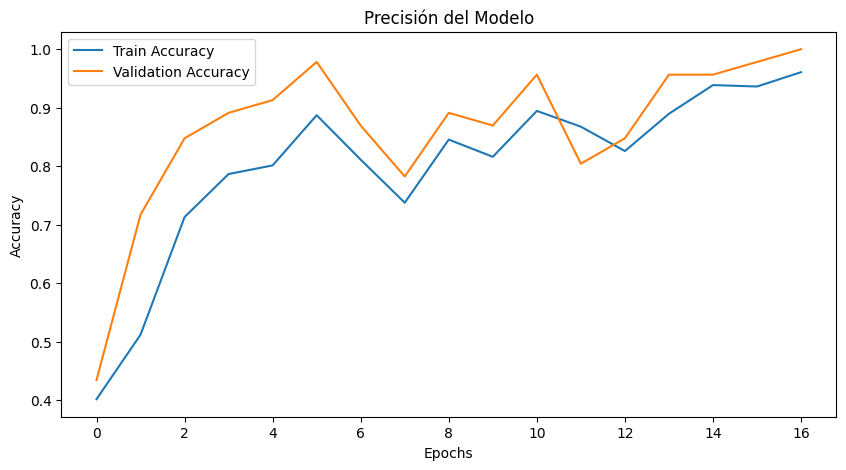

In [9]:
# 1. Gráfica de Pérdida (Loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Progreso del Entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2. Gráfica de Precisión (Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(history.history['categorical_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.title('Precisión del Modelo')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Accuracy Test

In [10]:
from tensorflow.keras.models import load_model

# Cargar el mejor modelo guardado durante el entrenamiento
best_model = load_model('mejor_modelo.keras')

# Evaluar el modelo cargado en los datos de prueba
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print(f'Accuracy en el conjunto de prueba: {accuracy*100:.2f}%')
print(f'Loss en el conjunto de prueba: {loss:.4f}')

Accuracy en el conjunto de prueba: 98.04%
Loss en el conjunto de prueba: 0.0393


Matriz de Confusión

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1000ms/step


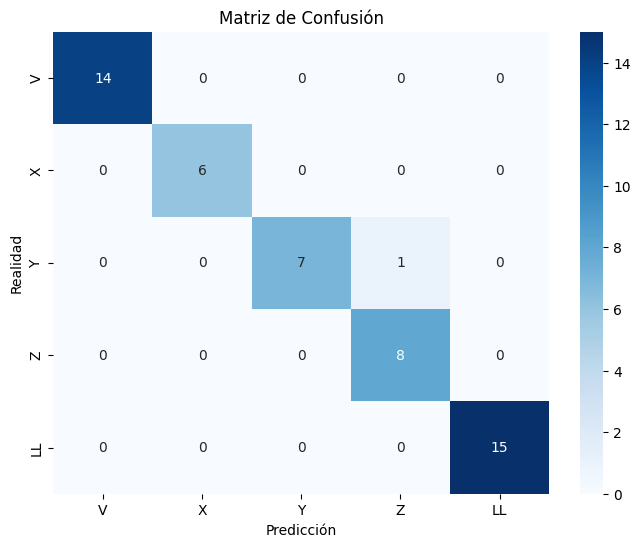

In [11]:
# Predecir sobre el conjunto de test
y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=actions, yticklabels=actions, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()

Guardar Modelo Final

In [16]:
model.save('modelo_dinamico.h5')
print("Modelo guardado como 'modelo_dinamico.h5'")

Modelo guardado como 'modelo_dinamico.h5'
